## IEEE-CIS Results Analysis and Comparison

Merging all model results...

--- FINAL MODEL PERFORMANCE RANKING ---
             Model  AUPRC (Primary)  ROC-AUC Min Cost/Tx  Optimal Threshold  Precision@0.5  Recall@0.5  F1@0.5
               lgb         0.497819 0.838794       $4.78               0.01         0.6963      0.4061  0.5130
               xgb         0.457735 0.824703       $4.39               0.01         0.4867      0.4525  0.4690
          mlp_prob         0.289590 0.829744       $2.19               0.01         0.2045      0.5952  0.3045
               iso         0.097109 0.771616       $2.22               0.01         0.0000      0.0000  0.0000
ae_semi_supervised         0.065948 0.720196      $17.37               0.01         0.0800      0.0019  0.0038
     ae_supervised         0.061134 0.707841      $17.37               0.01         0.0800      0.0019  0.0038
               lof         0.042495 0.567163      $17.37               0.28         0.0508      0.0010  0.0019

Error analysis completed for lgb.
Files s

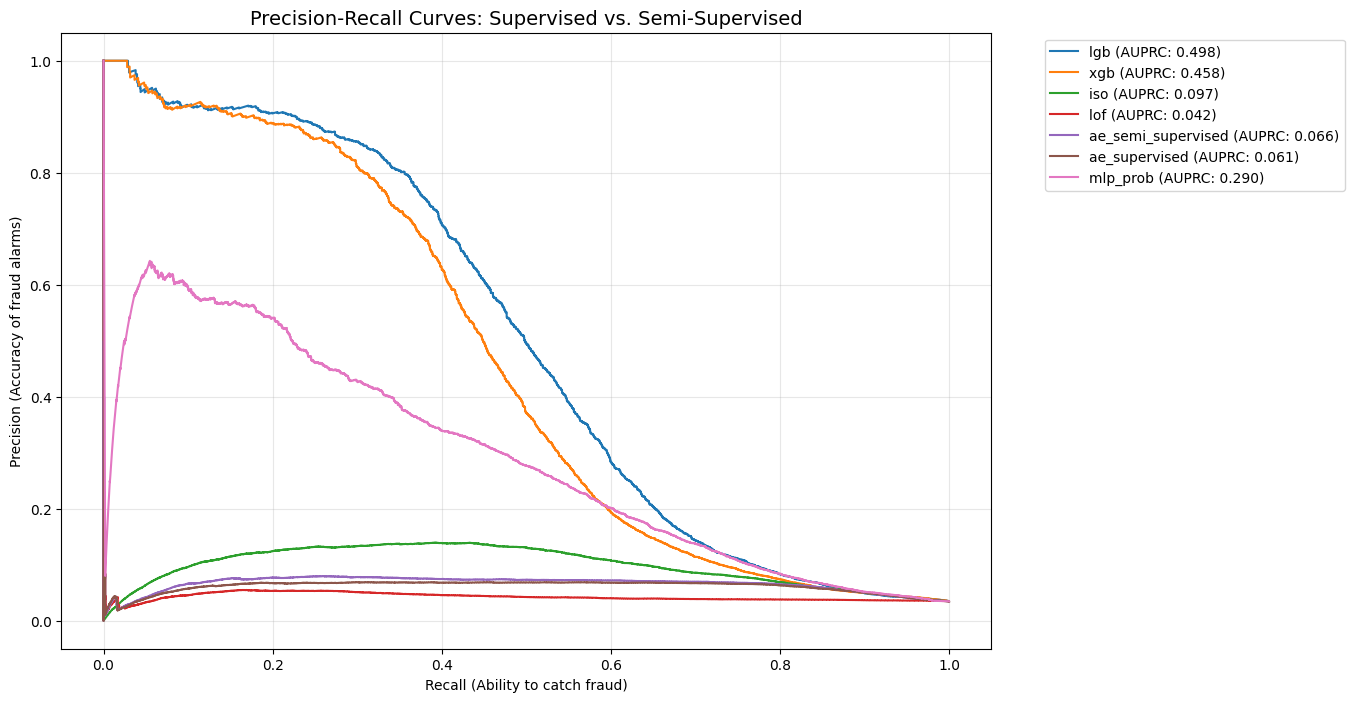

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score

# 1. LOAD AND MERGE
print("Merging all model results...")
ml_df = pd.read_csv('results/all_ml_probs.csv')
dl_df = pd.read_csv('results/dl_results.csv')
impact_df = pd.read_csv('results/feature_impact_results.csv')

# Combine into one master dataframe 
df = pd.concat([ml_df, dl_df.drop('actual', axis=1)], axis=1)

# Identify models (exclude the target)
models = [col for col in df.columns if col != 'actual']

# 2. COST-SENSITIVE EVALUATION ($500 FN vs $2 FP)
def calculate_business_cost(y_true, y_prob):
    thresholds = np.linspace(0.01, 0.99, 99)
    costs = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        # Total cost logic from rubric
        total_cost = (fn * 500) + (fp * 2)
        costs.append(total_cost / len(y_true)) 
    return thresholds, costs

# 3. GENERATE SUMMARY PERFORMANCE TABLE
summary_stats = []
plt.figure(figsize=(12, 8))

for m in models:
    # Autoencoder and Isolation Forest scores often need inversion if they represent "outlierness" 
    # but here we treat high = more likely fraud
    y_prob = df[m]
    
    # Standardize score ranges for metrics if necessary
    if y_prob.max() > 1.0 or y_prob.min() < 0:
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    
    aup_score = average_precision_score(df['actual'], y_prob)
    auc_score = roc_auc_score(df['actual'], y_prob)
    
    # Calculate optimal business cost
    thresh, costs = calculate_business_cost(df['actual'], y_prob)
    min_cost = np.min(costs)
    opt_thresh = thresh[np.argmin(costs)]
    
    y_pred_05 = (y_prob >= 0.5).astype(int)
    summary_stats.append({
        'Model': m,
        'AUPRC (Primary)': aup_score,
        'ROC-AUC': auc_score,
        'Min Cost/Tx': f"${min_cost:.2f}",
        'Optimal Threshold': opt_thresh,
        'Precision@0.5': round(precision_score(df['actual'], y_pred_05, zero_division=0), 4),
        'Recall@0.5':    round(recall_score(df['actual'],    y_pred_05, zero_division=0), 4),
        'F1@0.5':        round(f1_score(df['actual'],        y_pred_05, zero_division=0), 4)
    })
    
    # Plot PR Curve
    precision, recall, _ = precision_recall_curve(df['actual'], y_prob)
    plt.plot(recall, precision, label=f'{m} (AUPRC: {aup_score:.3f})')

# Formatting the PR Curve
plt.title('Precision-Recall Curves: Supervised vs. Semi-Supervised', fontsize=14)
plt.xlabel('Recall (Ability to catch fraud)')
plt.ylabel('Precision (Accuracy of fraud alarms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.savefig('report/final_pr_curves.png', bbox_inches='tight')

# 4. SHOW FINAL TABLE
results_table = pd.DataFrame(summary_stats).sort_values(by='AUPRC (Primary)', ascending=False)
print("\n--- FINAL MODEL PERFORMANCE RANKING ---")
print(results_table.to_string(index=False))
results_table.to_csv('report/final_model_comparison_table.csv', index=False)

# 5. CONFIDENT ERROR ANALYSIS (Manual Review)
# We use the top-performing model (likely LightGBM or MLP)
best_model_name = results_table.iloc[0]['Model']
df['prob'] = df[best_model_name]

# Confident False Positives: Model is 90%+ sure it's fraud, but it's not.
false_positives = df[(df['actual'] == 0)].sort_values(by='prob', ascending=False).head(10)

# Confident False Negatives: Model is 90%+ sure it's NOT fraud, but it is.
false_negatives = df[(df['actual'] == 1)].sort_values(by='prob', ascending=True).head(10)

false_positives.to_csv('report/top_10_false_positives.csv')
false_negatives.to_csv('report/top_10_false_negatives.csv')

print(f"\nError analysis completed for {best_model_name}.")
print("Files saved: 'final_pr_curves.png', 'final_model_comparison_table.csv', 'top_10_false_positives.csv', 'top_10_false_negatives.csv'")

F1-optimal threshold:   0.36  (F1 = 0.5180)
Cost-optimal threshold: 0.00  (Cost/Tx = $1.93)


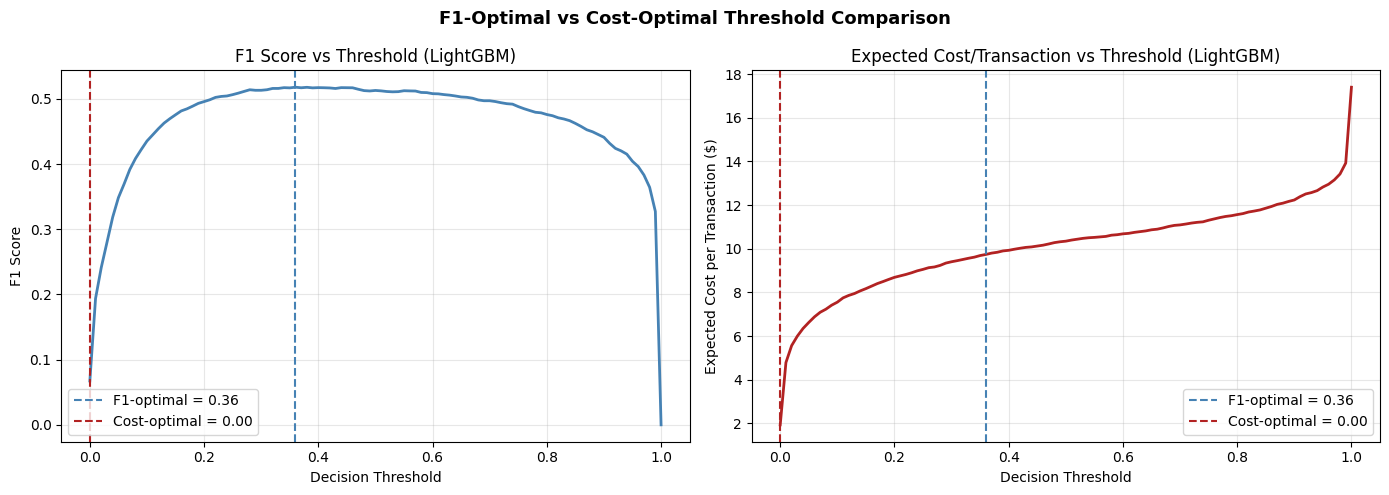


--- Threshold Comparison Summary ---
Criterion                  Threshold       F1    Cost/Tx
-------------------------------------------------------
Maximise F1                     0.36   0.5180 $     9.74
Minimise Cost                   0.00   0.0673 $     1.93


In [2]:
from sklearn.metrics import f1_score, precision_recall_fscore_support

# Use best model (LightGBM)
best_model_name = results_table.iloc[0]['Model']  # 'lgb'
y_prob = df[best_model_name].values
y_true = df['actual'].values

thresholds = np.linspace(0, 1, 101)

f1_scores = []
costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    # F1
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f1_scores.append(f1)
    
    # Cost
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    costs.append((fn * 500 + fp * 2) / len(y_true))

f1_scores = np.array(f1_scores)
costs = np.array(costs)

best_f1_thresh   = thresholds[np.argmax(f1_scores)]
best_cost_thresh = thresholds[np.argmin(costs)]

print(f"F1-optimal threshold:   {best_f1_thresh:.2f}  (F1 = {f1_scores.max():.4f})")
print(f"Cost-optimal threshold: {best_cost_thresh:.2f}  (Cost/Tx = ${costs.min():.2f})")

# Side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# F1 curve
ax1.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
ax1.axvline(best_f1_thresh, color='steelblue', linestyle='--', label=f'F1-optimal = {best_f1_thresh:.2f}')
ax1.axvline(best_cost_thresh, color='firebrick', linestyle='--', label=f'Cost-optimal = {best_cost_thresh:.2f}')
ax1.set_title('F1 Score vs Threshold (LightGBM)')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend()
ax1.grid(alpha=0.3)

# Cost curve
ax2.plot(thresholds, costs, color='firebrick', linewidth=2)
ax2.axvline(best_f1_thresh, color='steelblue', linestyle='--', label=f'F1-optimal = {best_f1_thresh:.2f}')
ax2.axvline(best_cost_thresh, color='firebrick', linestyle='--', label=f'Cost-optimal = {best_cost_thresh:.2f}')
ax2.set_title('Expected Cost/Transaction vs Threshold (LightGBM)')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('Expected Cost per Transaction ($)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('F1-Optimal vs Cost-Optimal Threshold Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/threshold_comparison.png', bbox_inches='tight')
plt.show()

# Summary table
print("\n--- Threshold Comparison Summary ---")
print(f"{'Criterion':<25} {'Threshold':>10} {'F1':>8} {'Cost/Tx':>10}")
print("-" * 55)
f1_at_cost = f1_scores[np.argmin(costs)]
cost_at_f1 = costs[np.argmax(f1_scores)]
print(f"{'Maximise F1':<25} {best_f1_thresh:>10.2f} {f1_scores.max():>8.4f} ${cost_at_f1:>9.2f}")
print(f"{'Minimise Cost':<25} {best_cost_thresh:>10.2f} {f1_at_cost:>8.4f} ${costs.min():>9.2f}")

## PaySim Results Analysis and Comparison

Merging all PaySim model results...


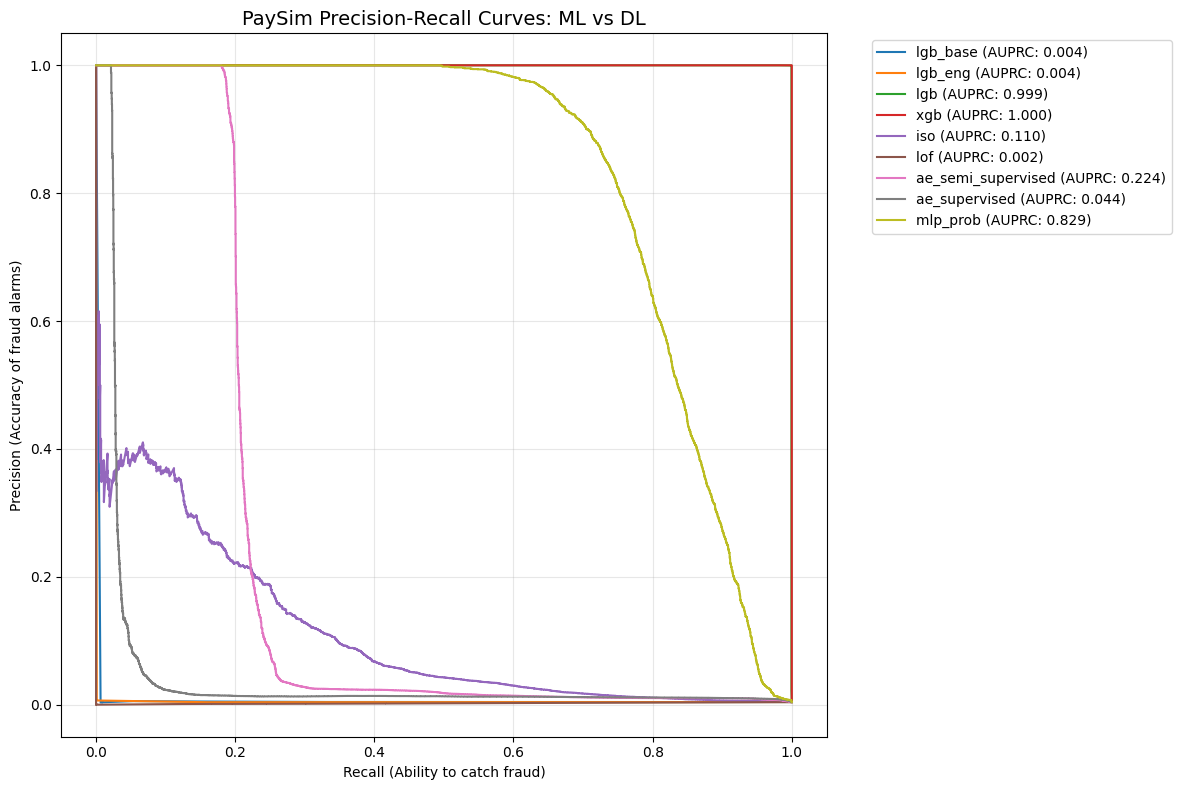


--- PAYSIM FINAL MODEL PERFORMANCE RANKING ---
             Model  AUPRC (Primary)  ROC-AUC Min Cost/Tx  Optimal Threshold
               xgb         1.000000 1.000000       $0.00               0.17
               lgb         0.999499 0.999704       $0.00               0.01
          mlp_prob         0.829190 0.983810       $0.19               0.03
ae_semi_supervised         0.223798 0.835977       $1.99               0.00
               iso         0.109812 0.840103       $0.96               0.09
     ae_supervised         0.044054 0.820287       $1.99               0.00
          lgb_base         0.004444 0.512590       $1.99               0.00
           lgb_eng         0.004166 0.495341       $1.99               0.00
               lof         0.002300 0.172576       $1.99               0.00

Error analysis completed for xgb.
Files saved: 'paysim_final_pr_curves.png', 'paysim_final_model_comparison_table.csv', 'paysim_top_10_false_positives.csv', 'paysim_top_10_false_negatives.csv

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score

# 1. LOAD AND MERGE PAYSIM RESULTS
print("Merging all PaySim model results...")

ml_df = pd.read_csv('results/paysim_all_ml_probs.csv')
dl_df = pd.read_csv('results/paysim_dl_results.csv')
impact_df = pd.read_csv('results/paysim_feature_impact_results.csv')

# Combine into one master dataframe
df = pd.concat([ml_df, dl_df.drop(columns=['actual'], errors='ignore')], axis=1)

# Identify models (exclude target)
models = [col for col in df.columns if col != 'actual']

# 2. COST-SENSITIVE EVALUATION
def calculate_business_cost(y_true, y_prob):
    thresholds = np.linspace(0, 1, 101)
    costs = []
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        
        # same business rule as IEEE notebook
        total_cost = (fn * 500) + (fp * 2)
        costs.append(total_cost / len(y_true))
        
    return thresholds, costs

# 3. GENERATE SUMMARY PERFORMANCE TABLE
summary_stats = []

plt.figure(figsize=(12, 8))

for m in models:
    y_prob = df[m].copy()

    # Standardize score ranges if necessary
    if y_prob.max() > 1.0 or y_prob.min() < 0:
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-12)

    aup_score = average_precision_score(df['actual'], y_prob)
    auc_score = roc_auc_score(df['actual'], y_prob)

    # Calculate optimal business cost
    thresh, costs = calculate_business_cost(df['actual'], y_prob)
    min_cost = np.min(costs)
    opt_thresh = thresh[np.argmin(costs)]

    summary_stats.append({
        'Model': m,
        'AUPRC (Primary)': aup_score,
        'ROC-AUC': auc_score,
        'Min Cost/Tx': f"${min_cost:.2f}",
        'Optimal Threshold': opt_thresh
    })

    # Plot PR Curve
    precision, recall, _ = precision_recall_curve(df['actual'], y_prob)
    plt.plot(recall, precision, label=f'{m} (AUPRC: {aup_score:.3f})')

# Formatting the PR Curve
plt.title('PaySim Precision-Recall Curves: ML vs DL', fontsize=14)
plt.xlabel('Recall (Ability to catch fraud)')
plt.ylabel('Precision (Accuracy of fraud alarms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('report/paysim_final_pr_curves.png', bbox_inches='tight')
plt.show()

# 4. SHOW FINAL TABLE
results_table = pd.DataFrame(summary_stats).sort_values(by='AUPRC (Primary)', ascending=False)
print("\n--- PAYSIM FINAL MODEL PERFORMANCE RANKING ---")
print(results_table.to_string(index=False))

results_table.to_csv('report/paysim_final_model_comparison_table.csv', index=False)

# 5. CONFIDENT ERROR ANALYSIS
best_model_name = results_table.iloc[0]['Model']
df['prob'] = df[best_model_name].copy()

# normalize again if needed
if df['prob'].max() > 1.0 or df['prob'].min() < 0:
    df['prob'] = (df['prob'] - df['prob'].min()) / (df['prob'].max() - df['prob'].min() + 1e-12)

false_positives = df[df['actual'] == 0].sort_values(by='prob', ascending=False).head(10)
false_negatives = df[df['actual'] == 1].sort_values(by='prob', ascending=True).head(10)

false_positives.to_csv('report/paysim_top_10_false_positives.csv', index=False)
false_negatives.to_csv('report/paysim_top_10_false_negatives.csv', index=False)

print(f"\nError analysis completed for {best_model_name}.")
print("Files saved: 'paysim_final_pr_curves.png', 'paysim_final_model_comparison_table.csv', 'paysim_top_10_false_positives.csv', 'paysim_top_10_false_negatives.csv'")

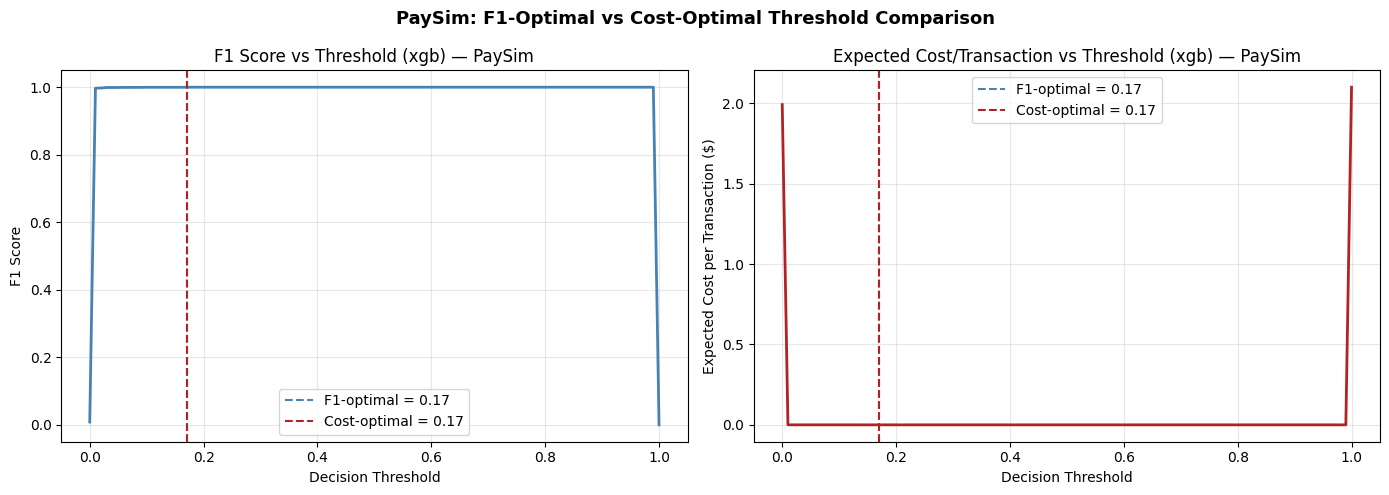


--- PaySim Threshold Comparison Summary ---
Criterion                  Threshold       F1    Cost/Tx
-------------------------------------------------------
Maximise F1                     0.17   1.0000 $     0.00
Minimise Cost                   0.17   1.0000 $     0.00


In [4]:
# --- PAYSIM THRESHOLD COMPARISON ---
best_model_name_ps = results_table.iloc[0]['Model']
y_prob_ps = df[best_model_name_ps].copy()
if y_prob_ps.max() > 1.0 or y_prob_ps.min() < 0:
    y_prob_ps = (y_prob_ps - y_prob_ps.min()) / (y_prob_ps.max() - y_prob_ps.min() + 1e-12)
y_prob_ps = y_prob_ps.values
y_true_ps = df['actual'].values

thresholds_ps = np.linspace(0, 1, 101)
f1_scores_ps, costs_ps = [], []

for t in thresholds_ps:
    y_pred = (y_prob_ps >= t).astype(int)
    f1_scores_ps.append(f1_score(y_true_ps, y_pred, zero_division=0))
    fn = ((y_true_ps == 1) & (y_pred == 0)).sum()
    fp = ((y_true_ps == 0) & (y_pred == 1)).sum()
    costs_ps.append((fn * 500 + fp * 2) / len(y_true_ps))

f1_scores_ps = np.array(f1_scores_ps)
costs_ps     = np.array(costs_ps)
best_f1_thresh_ps   = thresholds_ps[np.argmax(f1_scores_ps)]
best_cost_thresh_ps = thresholds_ps[np.argmin(costs_ps)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds_ps, f1_scores_ps, color='steelblue', linewidth=2)
ax1.axvline(best_f1_thresh_ps,   color='steelblue', linestyle='--', label=f'F1-optimal = {best_f1_thresh_ps:.2f}')
ax1.axvline(best_cost_thresh_ps, color='firebrick', linestyle='--', label=f'Cost-optimal = {best_cost_thresh_ps:.2f}')
ax1.set_title(f'F1 Score vs Threshold ({best_model_name_ps}) — PaySim')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(thresholds_ps, costs_ps, color='firebrick', linewidth=2)
ax2.axvline(best_f1_thresh_ps,   color='steelblue', linestyle='--', label=f'F1-optimal = {best_f1_thresh_ps:.2f}')
ax2.axvline(best_cost_thresh_ps, color='firebrick', linestyle='--', label=f'Cost-optimal = {best_cost_thresh_ps:.2f}')
ax2.set_title(f'Expected Cost/Transaction vs Threshold ({best_model_name_ps}) — PaySim')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('Expected Cost per Transaction ($)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('PaySim: F1-Optimal vs Cost-Optimal Threshold Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/paysim_threshold_comparison.png', bbox_inches='tight')
plt.show()

print("\n--- PaySim Threshold Comparison Summary ---")
print(f"{'Criterion':<25} {'Threshold':>10} {'F1':>8} {'Cost/Tx':>10}")
print("-" * 55)
print(f"{'Maximise F1':<25} {best_f1_thresh_ps:>10.2f} {f1_scores_ps.max():>8.4f} ${costs_ps[np.argmax(f1_scores_ps)]:>9.2f}")
print(f"{'Minimise Cost':<25} {best_cost_thresh_ps:>10.2f} {f1_scores_ps[np.argmin(costs_ps)]:>8.4f} ${costs_ps.min():>9.2f}")

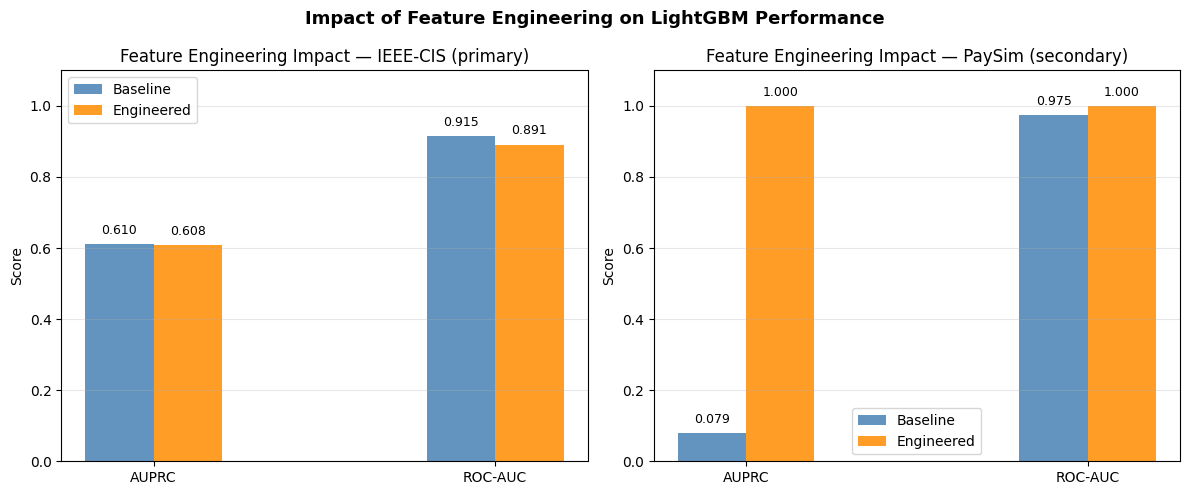

Saved: report/feature_impact_comparison.png


In [5]:
# --- FEATURE ENGINEERING IMPACT COMPARISON (both datasets) ---
ieee_impact   = pd.read_csv('results/feature_impact_results.csv').set_index('Metric')
paysim_impact = pd.read_csv('results/paysim_feature_impact_results.csv').set_index('Metric')

metrics   = ['AUPRC', 'ROC-AUC']
x         = np.arange(len(metrics))
width     = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, impact, title in zip(
    axes,
    [ieee_impact, paysim_impact],
    ['IEEE-CIS (primary)', 'PaySim (secondary)']
):
    baseline_vals = [impact.loc['AUPRC', 'Baseline'], impact.loc['ROC-AUC', 'Baseline']]
    eng_vals      = [impact.loc['AUPRC', 'Engineered'], impact.loc['ROC-AUC', 'Engineered']]

    bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline',   color='steelblue',  alpha=0.85)
    bars2 = ax.bar(x + width/2, eng_vals,      width, label='Engineered', color='darkorange',  alpha=0.85)

    ax.set_title(f'Feature Engineering Impact — {title}')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    for bar in bars1 + bars2:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Impact of Feature Engineering on LightGBM Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/feature_impact_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: report/feature_impact_comparison.png")